# Blood Cancer Classification Using EfficientNetB0 (PyTorch)

This notebook builds a unified multiclass classifier for hematological malignancy images using EfficientNetB0, Albumentations, and PyTorch.

## Target Classes

| Label | Class |
|---|---|
| 0 | Healthy |
| 1 | ALL |
| 2 | AML |
| 3 | Leukemia_CLL |
| 4 | CML |
| 5 | Lymphoma_CLL |
| 6 | FL |
| 7 | MCL |
| 8 | Myeloma |

## Notes

- Patient-wise splitting is applied for the lymphoma dataset, where patient IDs are recoverable from filenames.
- Leukemia and myeloma use their provided train/test folders, with an internal validation split created from the training portion.
- Class imbalance is handled with weighted cross entropy.

## 1. Install Dependencies

In [1]:
!pip install -q timm albumentations

## 2. Imports

In [2]:
import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm

import matplotlib.pyplot as plt
import seaborn as sns

## 3. Reproducibility

In [3]:
SEED = 42


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

## 4. Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Dataset Paths

In [5]:
# LYMPHOMA
lymphoma_cll_path = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/CLL"
fl_path = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/FL"
mcl_path = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/MCL"

# LEUKEMIA TRAIN
all_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/all train/all train"
aml_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/aml train/aml train"
leukemia_cll_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/cll train/cll train"
cml_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/cml/cml"
healthy_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/h train/h train"

# MYELOMA
myeloma_train = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x"
myeloma_val = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x"
myeloma_test = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/test/x"

# LEUKEMIA TEST
all_test_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/ALL TEST-20230225T082325Z-001/ALL TEST"
aml_test_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/AML TEST-20230225T082630Z-001/AML TEST"
cll_test_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/CLL TEST-20230225T082851Z-001/CLL TEST"
cml_test_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/CML TEST-20230225T083148Z-001/CML TEST"
healthy_test_path = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/test/test/H TEST-20230225T083612Z-001/H TEST"

## 6. Helper Functions

In [6]:
IMG_EXTENSIONS = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif"]


def get_all_images(folder_path):
    files = []
    for ext in IMG_EXTENSIONS:
        files.extend(glob.glob(os.path.join(folder_path, ext)))
    return sorted(files)


def extract_patient_id(filepath, label_name=None):
    filename = os.path.basename(filepath)
    stem = os.path.splitext(filename)[0]

    # Lymphoma example: sj-03-2810_001.tif -> sj-03-2810
    if label_name in {"Lymphoma_CLL", "FL", "MCL"} and "_" in stem:
        return stem.split("_")[0]

    # Fallback: use full stem when patient-level metadata is unavailable.
    return stem

## 7. Build Master DataFrame

In [7]:
rows = []


def add_class(folder, label_name):
    images = get_all_images(folder)
    for img in images:
        rows.append({
            "image_path": img,
            "label": label_name,
            "patient_id": extract_patient_id(img, label_name)
        })


# Lymphoma
add_class(lymphoma_cll_path, "Lymphoma_CLL")
add_class(fl_path, "FL")
add_class(mcl_path, "MCL")

# Leukemia
add_class(all_path, "ALL")
add_class(aml_path, "AML")
add_class(leukemia_cll_path, "Leukemia_CLL")
add_class(cml_path, "CML")
add_class(healthy_path, "Healthy")

# Myeloma
add_class(myeloma_train, "Myeloma")
add_class(myeloma_val, "Myeloma")

df = pd.DataFrame(rows).drop_duplicates(subset=["image_path"]).reset_index(drop=True)

print(df.head())
print("Total images:", len(df))

                                          image_path         label  patient_id
0  /kaggle/input/datasets/andrewmvd/malignant-lym...  Lymphoma_CLL  sj-03-2810
1  /kaggle/input/datasets/andrewmvd/malignant-lym...  Lymphoma_CLL  sj-03-2810
2  /kaggle/input/datasets/andrewmvd/malignant-lym...  Lymphoma_CLL  sj-03-2810
3  /kaggle/input/datasets/andrewmvd/malignant-lym...  Lymphoma_CLL  sj-03-2810
4  /kaggle/input/datasets/andrewmvd/malignant-lym...  Lymphoma_CLL  sj-03-2810
Total images: 15872


## 8. Encode Labels

In [8]:
label2id = {
    "Healthy": 0,
    "ALL": 1,
    "AML": 2,
    "Leukemia_CLL": 3,
    "CML": 4,
    "Lymphoma_CLL": 5,
    "FL": 6,
    "MCL": 7,
    "Myeloma": 8,
}

id2label = {v: k for k, v in label2id.items()}
df["target"] = df["label"].map(label2id)

print(df[["label", "target"]].drop_duplicates().sort_values("target"))

              label  target
12374       Healthy       0
374             ALL       1
3374            AML       2
6374   Leukemia_CLL       3
9374            CML       4
0      Lymphoma_CLL       5
113              FL       6
252             MCL       7
15374       Myeloma       8


## 9. Leakage-Safe / Dataset-Aware Splitting

In [9]:
# -----------------------------
# LYMPHOMA: patient-wise split
# -----------------------------
lymphoma_classes = ["Lymphoma_CLL", "FL", "MCL"]
lymphoma_df = df[df["label"].isin(lymphoma_classes)].copy()

lymphoma_patients = lymphoma_df["patient_id"].unique()
lymphoma_train_patients, lymphoma_test_patients = train_test_split(
    lymphoma_patients,
    test_size=0.20,
    random_state=SEED,
)

lymphoma_train_df = lymphoma_df[lymphoma_df["patient_id"].isin(lymphoma_train_patients)].copy()
lymphoma_test_df = lymphoma_df[lymphoma_df["patient_id"].isin(lymphoma_test_patients)].copy()

# -----------------------------
# LEUKEMIA: provided external test set,
# internal train/validation split
# -----------------------------
leukemia_classes = ["Healthy", "ALL", "AML", "Leukemia_CLL", "CML"]
leukemia_df = df[df["label"].isin(leukemia_classes)].copy()

train_df_leukemia, val_df_leukemia = train_test_split(
    leukemia_df,
    test_size=0.15,
    random_state=SEED,
    stratify=leukemia_df["target"],
)

# -----------------------------
# MYELOMA: provided external test set,
# internal train/validation split
# -----------------------------
myeloma_df = df[df["label"] == "Myeloma"].copy()

train_df_myeloma, val_df_myeloma = train_test_split(
    myeloma_df,
    test_size=0.15,
    random_state=SEED,
)

# -----------------------------
# FINAL TRAIN / VAL
# -----------------------------
train_df = pd.concat([
    lymphoma_train_df,
    train_df_leukemia,
    train_df_myeloma,
], ignore_index=True)

val_df = pd.concat([
    val_df_leukemia,
    val_df_myeloma,
], ignore_index=True)

# -----------------------------
# EXTERNAL TEST DATAFRAME
# -----------------------------
external_test_rows = []


def add_external_test(folder, label_name):
    images = get_all_images(folder)
    for img in images:
        external_test_rows.append({
            "image_path": img,
            "label": label_name,
            "patient_id": f"external::{label_name}::{extract_patient_id(img, label_name)}",
        })


add_external_test(all_test_path, "ALL")
add_external_test(aml_test_path, "AML")
add_external_test(cll_test_path, "Leukemia_CLL")
add_external_test(cml_test_path, "CML")
add_external_test(healthy_test_path, "Healthy")
add_external_test(myeloma_test, "Myeloma")

external_test_df = pd.DataFrame(external_test_rows)
external_test_df["target"] = external_test_df["label"].map(label2id)

# -----------------------------
# FINAL TEST
# -----------------------------
test_df = pd.concat([
    lymphoma_test_df,
    external_test_df,
], ignore_index=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class distribution\n")
print(train_df["label"].value_counts())

print("\nValidation class distribution\n")
print(val_df["label"].value_counts())

print("\nTest class distribution\n")
print(test_df["label"].value_counts())

print("\nTotal train images:", len(train_df))
print("Total validation images:", len(val_df))
print("Total test images:", len(test_df))

print("\nUnique train patients:", train_df["patient_id"].nunique())
print("Unique validation patients:", val_df["patient_id"].nunique())
print("Unique test patients:", test_df["patient_id"].nunique())

Train shape: (13473, 4)
Validation shape: (2325, 4)
Test shape: (5351, 4)

Train class distribution

label
AML             2550
Healthy         2550
Leukemia_CLL    2550
ALL             2550
CML             2550
Myeloma          423
FL               112
MCL               99
Lymphoma_CLL      89
Name: count, dtype: int64

Validation class distribution

label
Healthy         450
AML             450
Leukemia_CLL    450
CML             450
ALL             450
Myeloma          75
Name: count, dtype: int64

Test class distribution

label
AML             1000
Healthy         1000
ALL             1000
CML             1000
Leukemia_CLL    1000
Myeloma          277
FL                27
Lymphoma_CLL      24
MCL               23
Name: count, dtype: int64

Total train images: 13473
Total validation images: 2325
Total test images: 5351

Unique train patients: 13197
Unique validation patients: 2325
Unique test patients: 5283


## 10. Leakage Check

In [10]:
train_ids = set(train_df["patient_id"])
val_ids = set(val_df["patient_id"])
test_ids = set(test_df["patient_id"])

print("Train ∩ Val:", train_ids.intersection(val_ids))
print("Train ∩ Test:", train_ids.intersection(test_ids))
print("Val ∩ Test:", val_ids.intersection(test_ids))

Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()


## 11. Augmentations

In [11]:
IMAGE_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

## 12. Dataset Class

In [12]:
class BloodCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = row["target"]

        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        return image, torch.tensor(label, dtype=torch.long)

## 13. DataLoaders

In [13]:
BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

train_dataset = BloodCancerDataset(train_df, train_transform)
val_dataset = BloodCancerDataset(val_df, val_transform)
test_dataset = BloodCancerDataset(test_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 843
Validation batches: 146
Test batches: 335


## 14. Class Weights

In [14]:
class_counts = np.bincount(train_df["target"], minlength=len(label2id))
print("Class counts:", class_counts)

if (class_counts == 0).any():
    missing = [id2label[i] for i, c in enumerate(class_counts) if c == 0]
    raise ValueError(f"Missing classes in training split: {missing}")

weights = class_counts.sum() / (len(class_counts) * class_counts)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)

print("Class weights:", class_weights)

Class counts: [2550 2550 2550 2550 2550   89  112   99  423]
Class weights: tensor([ 0.5871,  0.5871,  0.5871,  0.5871,  0.5871, 16.8202, 13.3661, 15.1212,
         3.5390], device='cuda:0')


## 15. Model, Loss, Optimizer, Scheduler

In [15]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=len(label2id),
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5,
)

print(model.__class__.__name__)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet


## 16. Training and Validation Functions

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")
    return epoch_loss, epoch_acc, epoch_f1


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")
    return epoch_loss, epoch_acc, epoch_f1

## 17. Training Loop

In [17]:
EPOCHS = 15
best_f1 = 0.0
best_model_path = "best_model.pth"

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)

    scheduler.step(val_f1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1:   {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

print("\nBest validation F1:", round(best_f1, 4))


Epoch 1/15


  0%|          | 0/843 [00:00<?, ?it/s]

  0%|          | 0/146 [00:00<?, ?it/s]

Train Loss: 0.6317 | Train Acc: 0.8379 | Train F1: 0.8429
Val Loss:   0.0421 | Val Acc:   0.9854 | Val F1:   0.9856
Best model saved.

Epoch 2/15


  0%|          | 0/843 [00:00<?, ?it/s]

...

  0%|          | 0/146 [00:00<?, ?it/s]

Train Loss: 0.0657 | Train Acc: 0.9906 | Train F1: 0.9906
Val Loss:   0.0008 | Val Acc:   0.9996 | Val F1:   0.9996

Epoch 15/15


  0%|          | 0/843 [00:00<?, ?it/s]

  0%|          | 0/146 [00:00<?, ?it/s]

Train Loss: 0.0540 | Train Acc: 0.9906 | Train F1: 0.9906
Val Loss:   0.0018 | Val Acc:   0.9996 | Val F1:   0.9996

Best validation F1: 1.0


## 18. Epoch-Wise Training Statistics

In [18]:
history_df = pd.DataFrame({
    "Epoch": list(range(1, EPOCHS + 1)),
    "Train Loss": train_losses,
    "Validation Loss": val_losses,
    "Train Accuracy": train_accs,
    "Validation Accuracy": val_accs,
    "Train F1": train_f1s,
    "Validation F1": val_f1s,
})

history_df

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Train F1,Validation F1
0,1,0.631726,0.042142,0.837898,0.985376,0.842949,0.985638
1,2,0.319108,0.023888,0.936985,0.992688,0.937414,0.992691
2,3,0.261864,0.014407,0.953908,0.995269,0.954239,0.995268
3,4,0.226176,0.002656,0.964819,0.999570,0.964973,0.999570
4,5,0.211050,0.030888,0.969346,0.993978,0.969464,0.994397
5,6,0.186076,0.009932,0.973131,0.996559,0.973192,0.996563
6,7,0.173951,0.016330,0.973799,0.995699,0.973956,0.996539
7,8,0.111813,0.001001,0.982261,1.000000,0.982257,1.000000
8,9,0.118139,0.008413,0.982558,0.997849,0.982596,0.998277
9,10,0.107642,0.008261,0.985527,0.997849,0.985541,0.997848


## 19. Plot F1 Scores

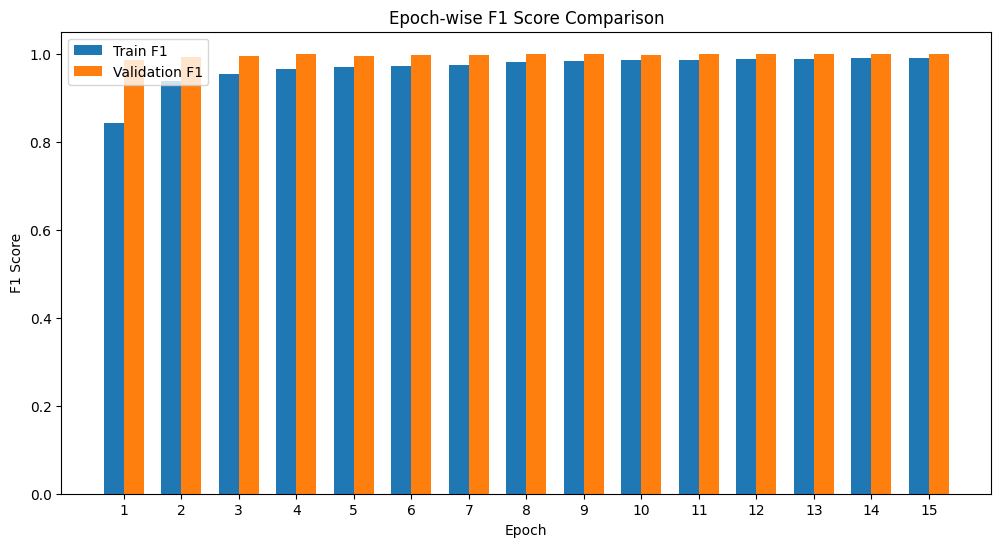

In [19]:
plt.figure(figsize=(12, 6))

x = np.arange(EPOCHS)
width = 0.35

plt.bar(x - width / 2, train_f1s, width, label="Train F1")
plt.bar(x + width / 2, val_f1s, width, label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Epoch-wise F1 Score Comparison")
plt.xticks(x, range(1, EPOCHS + 1))
plt.legend()
plt.show()

## 20. Plot Training Curves

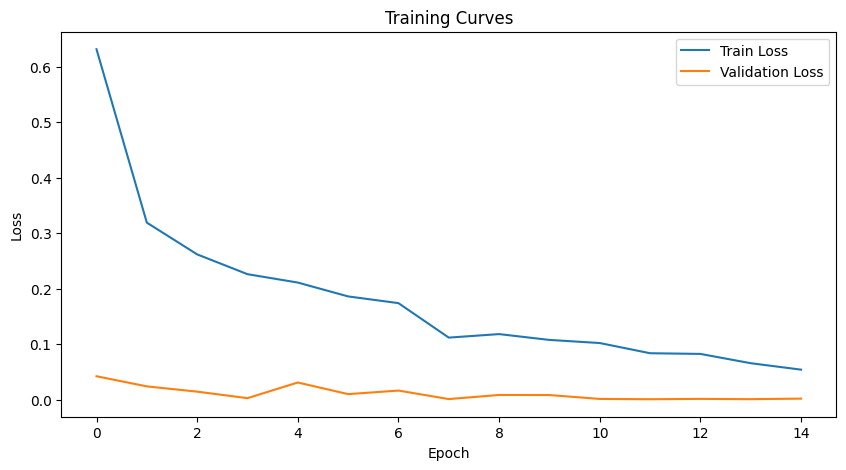

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curves")
plt.legend()
plt.show()

## 21. Load Best Model

In [21]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

## 22. Test Evaluation

In [22]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Test Accuracy:", round(accuracy_score(all_labels, all_preds), 4))
print("Test Weighted F1:", round(f1_score(all_labels, all_preds, average="weighted"), 4))

  0%|          | 0/335 [00:00<?, ?it/s]

Test Accuracy: 0.7853
Test Weighted F1: 0.7129


## 23. Classification Report

In [23]:
target_names = [id2label[i] for i in range(len(id2label))]

print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(target_names))),
    target_names=target_names,
    zero_division=0,
))

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1000
         ALL       0.00      0.00      0.00      1000
         AML       0.58      0.97      0.72      1000
Leukemia_CLL       0.81      0.91      0.86      1000
         CML       0.85      1.00      0.92      1000
Lymphoma_CLL       0.38      0.50      0.43        24
          FL       0.77      0.63      0.69        27
         MCL       0.48      0.43      0.45        23
     Myeloma       0.99      1.00      1.00       277

    accuracy                           0.79      5351
   macro avg       0.65      0.72      0.67      5351
weighted avg       0.66      0.79      0.71      5351



## 24. Confusion Matrix

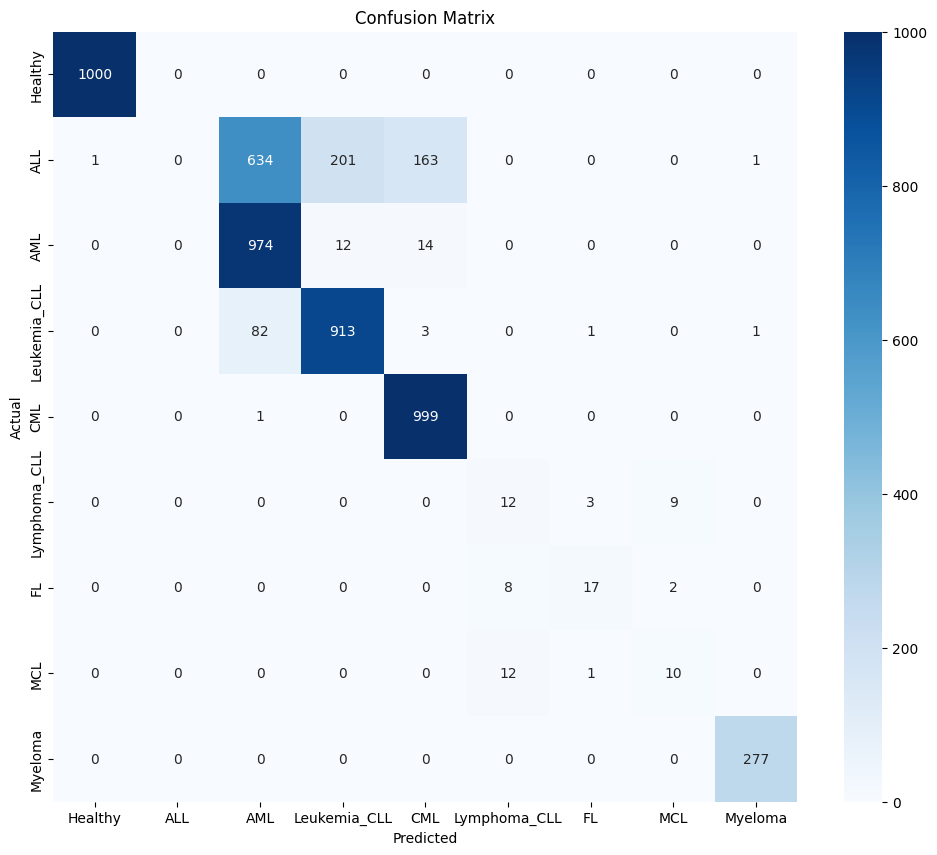

In [24]:
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(label2id))))

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 25. Inference Helper

In [25]:
def predict_image(image_path):
    model.eval()

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    transformed = val_transform(image=image)
    image_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        pred = torch.argmax(outputs, dim=1).item()

    return id2label[pred]

## 26. Example Prediction

In [26]:
sample = test_df.iloc[0]["image_path"]
print("Sample path:", sample)
print("Predicted class:", predict_image(sample))

Sample path: /kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/CLL/sj-05-3874-R2_001.tif
Predicted class: Lymphoma_CLL


## Suggested Future Improvements

1. Grad-CAM or other explainability methods
2. Focal loss for stronger imbalance handling
3. Test-time augmentation
4. EfficientNetB3/B4 or ConvNeXt backbones
5. Hierarchical routing across disease families
6. Self-supervised or domain-specific pretraining